## **Loading dataset**

In [7]:
from google.colab import files
uploaded = files.upload()

print(uploaded)

Saving sales_dataset.csv to sales_dataset.csv
{'sales_dataset.csv': b'TV,Radio,Newspaper,Sales\r\n230.1,37.8,69.2,22.1\r\n44.5,39.3,45.1,10.4\r\n17.2,45.9,69.3,12\r\n151.5,41.3,58.5,16.5\r\n180.8,10.8,58.4,17.9\r\n8.7,48.9,75,7.2\r\n57.5,32.8,23.5,11.8\r\n120.2,19.6,11.6,13.2\r\n8.6,2.1,1,4.8\r\n199.8,2.6,21.2,15.6\r\n66.1,5.8,24.2,12.6\r\n214.7,24,4,17.4\r\n23.8,35.1,65.9,9.2\r\n97.5,7.6,7.2,13.7\r\n204.1,32.9,46,19\r\n195.4,47.7,52.9,22.4\r\n67.8,36.6,114,12.5\r\n281.4,39.6,55.8,24.4\r\n69.2,20.5,18.3,11.3\r\n147.3,23.9,19.1,14.6\r\n218.4,27.7,53.4,18\r\n237.4,5.1,23.5,17.5\r\n13.2,15.9,49.6,5.6\r\n228.3,16.9,26.2,20.5\r\n62.3,12.6,18.3,9.7\r\n262.9,3.5,19.5,17\r\n142.9,29.3,12.6,15\r\n240.1,16.7,22.9,20.9\r\n248.8,27.1,22.9,18.9\r\n70.6,16,40.8,10.5\r\n292.9,28.3,43.2,21.4\r\n112.9,17.4,38.6,11.9\r\n97.2,1.5,30,13.2\r\n265.6,20,0.3,17.4\r\n95.7,1.4,7.4,11.9\r\n290.7,4.1,8.5,17.8\r\n266.9,43.8,5,25.4\r\n74.7,49.4,45.7,14.7\r\n43.1,26.7,35.1,10.1\r\n228,37.7,32,21.5\r\n202.5,22.3,31.6

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

import seaborn as sns
sns.set_style("whitegrid")

In [16]:
df =pd.read_csv("sales_dataset.csv")
print("datset loaded sucessfully")

datset loaded sucessfully


In [18]:
df.head(20)

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
5,8.7,48.9,75.0,7.2
6,57.5,32.8,23.5,11.8
7,120.2,19.6,11.6,13.2
8,8.6,2.1,1.0,4.8
9,199.8,2.6,21.2,15.6


## **Checking Missing values**

In [19]:
df.isnull().sum()
df.shape
df.dtypes

,0
TV,float64
Radio,float64
Newspaper,float64
Sales,float64


## **Creating Vizualizations**

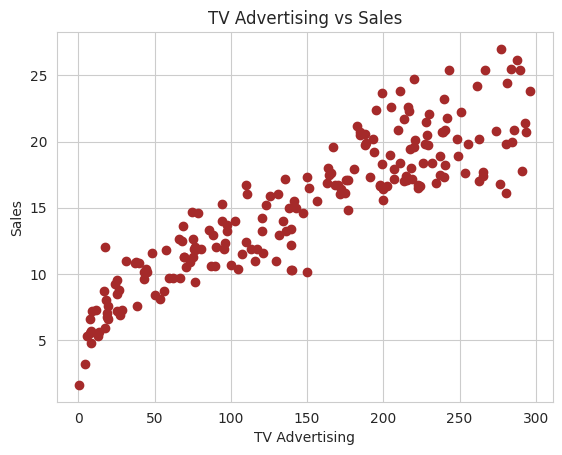

In [21]:
plt.scatter(df['TV'], df['Sales'], color='brown')
plt.xlabel('TV Advertising')
plt.ylabel('Sales')
plt.title('TV Advertising vs Sales')
plt.show()

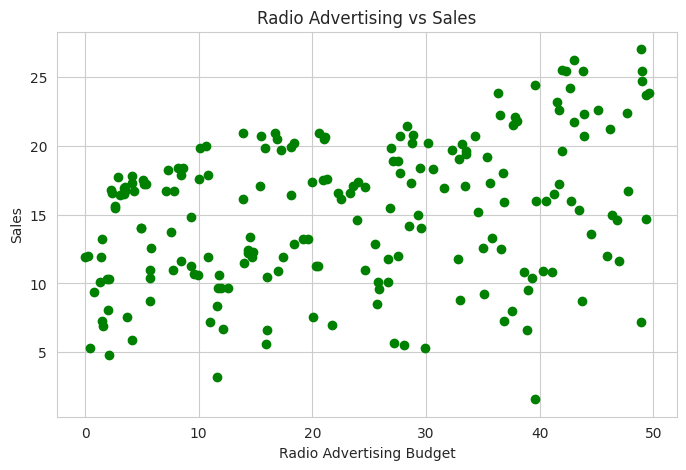

In [23]:
plt.figure(figsize=(8,5))
plt.scatter(df['Radio'], df['Sales'], color='green')
plt.title('Radio Advertising vs Sales')
plt.xlabel('Radio Advertising Budget')
plt.ylabel('Sales')
plt.show()

Text(0, 0.5, 'sales')

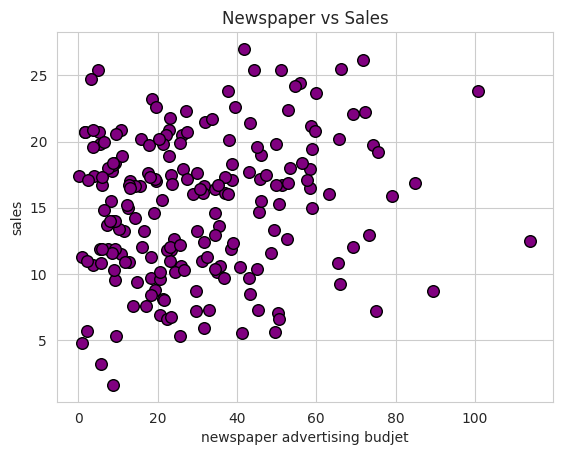

In [24]:
plt.scatter(df['Newspaper'], df['Sales'],
            color='purple',
            edgecolors='black',
            s=70)
plt.title("Newspaper vs Sales")
plt.xlabel("newspaper advertising budjet")
plt.ylabel("sales")

In [26]:
df.columns

Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [34]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

X.head()

,TV,Radio,Newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4


## **Splitting Data Set**

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (160, 3)
X_test: (40, 3)
y_train: (160,)
y_test: (40,)


## **Model Selection And Train Data**

In [38]:
model = LinearRegression()
model.fit(X_train, y_train)
print("Model Trained Successfully!")
y_pred = model.predict(X_test)

results = pd.DataFrame({
    'Actual Sales': y_test.values,
    'Predicted Sales': y_pred
})

results.head(10)

Model Trained Successfully!


,Actual Sales,Predicted Sales
0,16.9,17.034772
1,22.4,20.409740
2,21.4,23.723989
3,7.3,9.272785
4,24.7,21.682719
5,12.6,12.569402
6,22.3,21.081195
7,8.4,8.690350
8,16.5,17.237013
9,16.1,16.666575


## **Calculating Mean Absolute Error(MAE)**

In [40]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 1.2748262109549338


In [41]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.9059011844150826


### **Adding new DataFrame To Test The Model**

In [43]:
new_data = pd.DataFrame({
    'TV': [250, 100, 50],
    'Radio': [35, 20, 10],
    'Newspaper': [40, 15, 5]
})

predictions = model.predict(new_data)

results = new_data.copy()
results['Predicted Sales'] = predictions

results

,TV,Radio,Newspaper,Predicted Sales
0,250,35,40,22.047998
1,100,20,15,12.249010
2,50,10,5,8.470727
